# 05 — Baseline Modeling Before Ensembles

This notebook follows the usual modeling pattern: start with simple models, measure their limitations, and use evidence to decide which ensemble technique should come next. The test set remains untouched.

## Install required packages

In [1]:
%pip install pandas numpy scipy scikit-learn joblib matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, brier_score_loss, classification_report,
    ConfusionMatrixDisplay, log_loss, precision_recall_curve,
    PrecisionRecallDisplay, RocCurveDisplay, roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from IPython.display import display, Markdown

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")

current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in [current_dir, *current_dir.parents] if (path / "data" / "processed" / "engineered").exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find the engineered data directory.")

engineered_dir = project_root / "data" / "processed" / "engineered"
model_dir = project_root / "models" / "baselines"
model_dir.mkdir(parents=True, exist_ok=True)

## Modeling strategy

We compare three levels of complexity:

1. **Dummy classifier:** predicts the training click rate and provides the minimum benchmark.
2. **Logistic regression:** tests whether a mainly linear pattern is sufficient.
3. **Single decision tree:** tests nonlinear rules and interactions, but may overfit.

Because clicks are uncommon, PR-AUC is the primary metric. ROC-AUC measures ranking, while log loss and Brier score measure probability quality. Accuracy is not used as the main metric.

## Load the selected-feature train and validation data

In [3]:
train = pd.read_csv(engineered_dir / "train_top6_engineered.csv", parse_dates=["event_ts"])
validation = pd.read_csv(engineered_dir / "validation_top6_engineered.csv", parse_dates=["event_ts"])
with (engineered_dir / "feature_metadata.json").open() as file:
    feature_metadata = json.load(file)

target = "clicked"
selected_derived_features = feature_metadata["selected_derived_features"]
print(f"Training shape: {train.shape}")
print(f"Validation shape: {validation.shape}")
print(f"Selected derived features: {selected_derived_features}")
print(f"Training CTR: {train[target].mean():.2%}")
print(f"Validation CTR: {validation[target].mean():.2%}")

Training shape: (315000, 28)
Validation shape: (67500, 28)
Selected derived features: ['product_past_ctr', 'user_product_ctr_gap', 'product_past_clicks', 'category_past_ctr', 'brand_past_ctr', 'category_page_ctr_gap']
Training CTR: 6.82%
Validation CTR: 7.01%


## Select predictors and build leakage-safe preprocessing

In [4]:
# IDs and raw timestamps are retained for auditing, not used as direct predictors.
excluded_columns = ["impression_id", "event_ts", "product_name", target]
numeric_features = [
    "slot_position", "hour_of_day", "price_usd", "discount_pct",
    "avg_rating", "review_count", "age", *selected_derived_features,
]
categorical_features = [
    "user_id", "product_id", "platform", "device_os", "page_type",
    "day_of_week", "brand", "category", "gender", "city", "loyalty_tier",
]
feature_columns = numeric_features + categorical_features

for frame in [train, validation]:
    frame.replace([np.inf, -np.inf], np.nan, inplace=True)
    for column in categorical_features:
        frame[column] = frame[column].astype("string")

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler(with_mean=False)),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore", min_frequency=10, dtype=np.float32)),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
], sparse_threshold=1.0)

X_train = train[feature_columns]
y_train = train[target].astype("int8")
X_validation = validation[feature_columns]
y_validation = validation[target].astype("int8")

## Define the baseline models

In [5]:
models = {
    "dummy": DummyClassifier(strategy="prior"),
    "logistic_regression": LogisticRegression(
        max_iter=1_000, solver="liblinear", random_state=RANDOM_STATE
    ),
    "decision_tree": DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=100, class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
}

pipelines = {
    name: Pipeline([("preprocessor", preprocessor), ("model", model)])
    for name, model in models.items()
}

## Train and evaluate each normal baseline

In [6]:
def probability_metrics(y_true, probability):
    return {
        "pr_auc": average_precision_score(y_true, probability),
        "roc_auc": roc_auc_score(y_true, probability),
        "log_loss": log_loss(y_true, probability),
        "brier_score": brier_score_loss(y_true, probability),
    }

results = []
probabilities = {}
for name, pipeline in pipelines.items():
    start = time.perf_counter()
    pipeline.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start
    train_probability = pipeline.predict_proba(X_train)[:, 1]
    validation_probability = pipeline.predict_proba(X_validation)[:, 1]
    probabilities[name] = validation_probability

    train_metrics = probability_metrics(y_train, train_probability)
    validation_metrics = probability_metrics(y_validation, validation_probability)
    results.append({
        "model": name,
        "fit_seconds": fit_seconds,
        **{f"train_{metric}": value for metric, value in train_metrics.items()},
        **{f"validation_{metric}": value for metric, value in validation_metrics.items()},
        "pr_auc_gap": train_metrics["pr_auc"] - validation_metrics["pr_auc"],
    })

results_df = pd.DataFrame(results).set_index("model").sort_values("validation_pr_auc", ascending=False)
display(results_df)

,fit_seconds,train_pr_auc,train_roc_auc,train_log_loss,train_brier_score,validation_pr_auc,validation_roc_auc,validation_log_loss,validation_brier_score,pr_auc_gap
model,,,,,,,,,,
decision_tree,4.5647,0.2259,0.7776,0.5672,0.1948,0.2277,0.7643,0.5850,0.1981,-0.0018
logistic_regression,8.2470,0.3140,0.8350,0.1975,0.0546,0.1985,0.7566,0.2249,0.0607,0.1155
dummy,1.8210,0.0682,0.5000,0.2490,0.0636,0.0701,0.5000,0.2539,0.0652,-0.0019


## Compare ranking curves

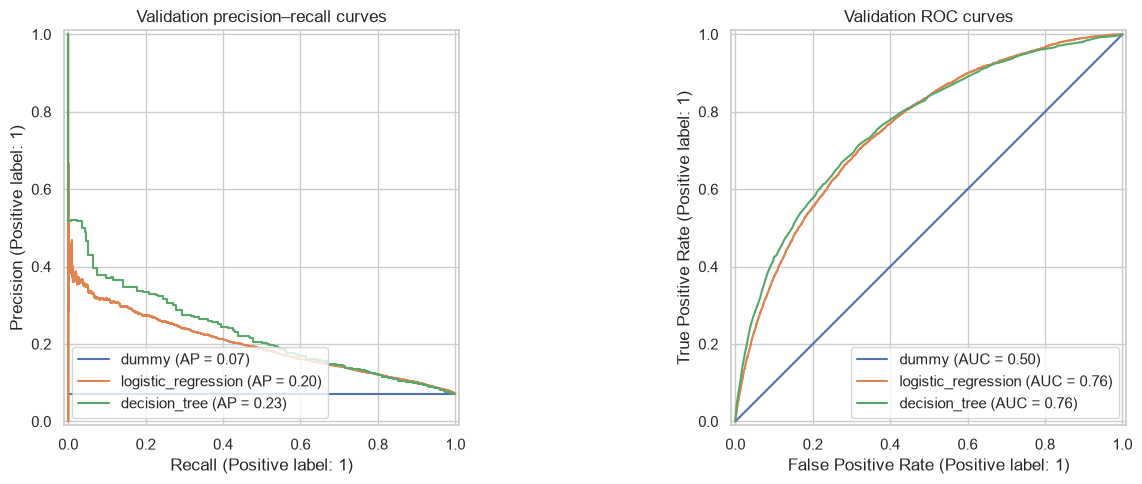

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, probability in probabilities.items():
    PrecisionRecallDisplay.from_predictions(y_validation, probability, name=name, ax=axes[0])
    RocCurveDisplay.from_predictions(y_validation, probability, name=name, ax=axes[1])
axes[0].set_title("Validation precision–recall curves")
axes[1].set_title("Validation ROC curves")
plt.tight_layout()
plt.show()

## Check probability calibration

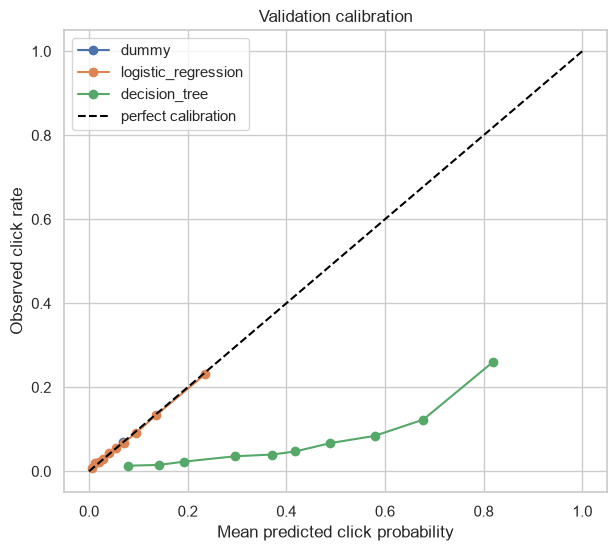

In [8]:
plt.figure(figsize=(7, 6))
for name, probability in probabilities.items():
    observed, predicted = calibration_curve(y_validation, probability, n_bins=10, strategy="quantile")
    plt.plot(predicted, observed, marker="o", label=name)
plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="perfect calibration")
plt.xlabel("Mean predicted click probability")
plt.ylabel("Observed click rate")
plt.title("Validation calibration")
plt.legend()
plt.show()

## Inspect a practical classification threshold

The business has not supplied click and non-click costs, so 0.50 is not assumed to be optimal. The example below selects the threshold with the highest validation F1 score. This is diagnostic only.

Best validation model: decision_tree
Diagnostic F1 threshold: 0.7325
              precision    recall  f1-score   support

           0     0.9520    0.9155    0.9333     62768
           1     0.2566    0.3872    0.3087      4732

    accuracy                         0.8784     67500
   macro avg     0.6043    0.6513    0.6210     67500
weighted avg     0.9032    0.8784    0.8896     67500



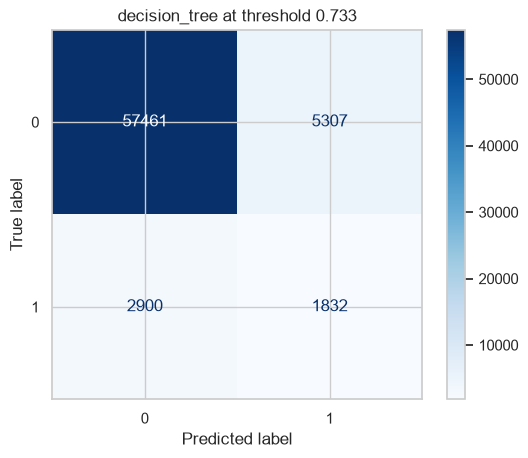

In [9]:
best_model_name = results_df.index[0]
best_probability = probabilities[best_model_name]
precision, recall, thresholds = precision_recall_curve(y_validation, best_probability)
f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
best_threshold_index = int(np.nanargmax(f1))
selected_threshold = float(thresholds[best_threshold_index])
validation_prediction = (best_probability >= selected_threshold).astype(int)

print(f"Best validation model: {best_model_name}")
print(f"Diagnostic F1 threshold: {selected_threshold:.4f}")
print(classification_report(y_validation, validation_prediction, digits=4))
ConfusionMatrixDisplay.from_predictions(y_validation, validation_prediction, cmap="Blues")
plt.title(f"{best_model_name} at threshold {selected_threshold:.3f}")
plt.show()

## Diagnose why a normal model may not be enough

In [10]:
dummy_pr_auc = results_df.loc["dummy", "validation_pr_auc"]
logistic_pr_auc = results_df.loc["logistic_regression", "validation_pr_auc"]
tree_train_pr_auc = results_df.loc["decision_tree", "train_pr_auc"]
tree_validation_pr_auc = results_df.loc["decision_tree", "validation_pr_auc"]
logistic_lift = logistic_pr_auc / dummy_pr_auc if dummy_pr_auc else np.nan
tree_gap = tree_train_pr_auc - tree_validation_pr_auc
tree_beats_logistic = tree_validation_pr_auc > logistic_pr_auc

diagnosis = pd.Series({
    "dummy validation PR-AUC": dummy_pr_auc,
    "logistic validation PR-AUC": logistic_pr_auc,
    "logistic PR-AUC lift over dummy": logistic_lift,
    "tree training PR-AUC": tree_train_pr_auc,
    "tree validation PR-AUC": tree_validation_pr_auc,
    "tree overfit gap": tree_gap,
    "tree beats logistic on validation": tree_beats_logistic,
})
display(diagnosis.to_frame("value"))

,value
dummy validation PR-AUC,0.0701
logistic validation PR-AUC,0.1985
logistic PR-AUC lift over dummy,2.8318
tree training PR-AUC,0.2259
tree validation PR-AUC,0.2277
tree overfit gap,-0.0018
tree beats logistic on validation,True


## Decide which ensemble family to test next

In [11]:
if tree_gap > 0.03:
    ensemble_choice = "Bagging or Random Forest"
    reason = "The single tree has a noticeable train–validation gap. Averaging many trees can reduce its variance and overfitting."
elif tree_beats_logistic:
    ensemble_choice = "Gradient Boosting"
    reason = "The tree beats the linear model without a large overfit gap, suggesting useful nonlinear patterns that boosting can refine."
else:
    ensemble_choice = "Gradient Boosting, compared carefully with logistic regression"
    reason = "The single tree does not clearly improve on the linear model. Boosting can test whether smaller sequential trees capture useful residual patterns."

display(Markdown(f"""
### Evidence-based next model

**Recommended ensemble family:** {ensemble_choice}

**Reason:** {reason}

This is a modeling recommendation, not a claim that the baseline has failed. A business success threshold has not been provided. The ensemble must beat the best baseline on validation PR-AUC and should not materially worsen log loss or calibration.
"""))


### Evidence-based next model

**Recommended ensemble family:** Gradient Boosting

**Reason:** The tree beats the linear model without a large overfit gap, suggesting useful nonlinear patterns that boosting can refine.

This is a modeling recommendation, not a claim that the baseline has failed. A business success threshold has not been provided. The ensemble must beat the best baseline on validation PR-AUC and should not materially worsen log loss or calibration.


## Save baseline models and results

In [12]:
for name, pipeline in pipelines.items():
    joblib.dump(pipeline, model_dir / f"{name}.joblib")
results_df.to_csv(model_dir / "baseline_validation_results.csv")

baseline_metadata = {
    "target": target,
    "primary_metric": "validation_pr_auc",
    "best_baseline": best_model_name,
    "diagnostic_threshold": selected_threshold,
    "recommended_ensemble_family": ensemble_choice,
    "ensemble_reason": reason,
    "test_set_used": False,
}
with (model_dir / "baseline_metadata.json").open("w") as file:
    json.dump(baseline_metadata, file, indent=2)
print(f"Saved baseline artifacts to: {model_dir}")

Saved baseline artifacts to: /Users/namees.local/Desktop/ensamble_technique/models/baselines


## Baseline modeling recap

In [13]:
best_row = results_df.iloc[0]
display(Markdown(f"""
### What we learned

- Three normal baselines were tested: a dummy model, logistic regression, and one decision tree.
- The best baseline is **{best_model_name}**, with validation PR-AUC **{best_row['validation_pr_auc']:.4f}**, ROC-AUC **{best_row['validation_roc_auc']:.4f}**, log loss **{best_row['validation_log_loss']:.4f}**, and Brier score **{best_row['validation_brier_score']:.4f}**.
- Logistic regression achieved **{logistic_lift:.2f}×** the dummy PR-AUC. This measures improvement over simply predicting the average click rate.
- The decision tree's train–validation PR-AUC gap is **{tree_gap:.4f}**. A large positive gap indicates overfitting.
- Based on these patterns, the next ensemble family to test is **{ensemble_choice}**.
- The test set was not loaded or evaluated. It remains untouched for final model assessment.

### Next step

Create an ensemble notebook, compare the recommended ensemble against these exact baselines on validation data, and proceed only if the improvement is meaningful.
"""))


### What we learned

- Three normal baselines were tested: a dummy model, logistic regression, and one decision tree.
- The best baseline is **decision_tree**, with validation PR-AUC **0.2277**, ROC-AUC **0.7643**, log loss **0.5850**, and Brier score **0.1981**.
- Logistic regression achieved **2.83×** the dummy PR-AUC. This measures improvement over simply predicting the average click rate.
- The decision tree's train–validation PR-AUC gap is **-0.0018**. A large positive gap indicates overfitting.
- Based on these patterns, the next ensemble family to test is **Gradient Boosting**.
- The test set was not loaded or evaluated. It remains untouched for final model assessment.

### Next step

Create an ensemble notebook, compare the recommended ensemble against these exact baselines on validation data, and proceed only if the improvement is meaningful.
